<a href="https://colab.research.google.com/github/Leeloo-Kikontwe/Codveda_Technologies_Machine_Learning_Internship/blob/main/Task3/Task1_Level2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MOUNTING GOOGLE DRIVE TO ACCESS THE DATASET

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORTING THE LIBRARIES

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

LOADING THE DATASETS

In [3]:
#Import the training dataset
df_train_path = '/content/drive/MyDrive/Data_Set_For_Task/Data_Set_For_Task/Churn Prdiction Data/churn-bigml-80.csv'
df_train = pd.read_csv(df_train_path)


In [4]:
#Importing the testing set
df_test_path = '/content/drive/MyDrive/Data_Set_For_Task/Data_Set_For_Task/Churn Prdiction Data/churn-bigml-20.csv'
df_test = pd.read_csv(df_test_path)

In [5]:
data = df_train.copy()
test_data = df_test.copy()

In [6]:
data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


EXPLORATORY DATA ANALYSIS (EDA) ON THE TRAINING DATASET

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [8]:
#Check the number of rows and columns
data.shape

(2666, 20)

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [10]:
data.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
#check for null values
data.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [12]:
#check if there is any duplicate values
data.duplicated().sum()

np.int64(0)

In [13]:
#Identify the categorical features
train_cat = data.select_dtypes(exclude=["number", "bool","float"])
train_cat.head()

,State,International plan,Voice mail plan
0,KS,No,Yes
1,OH,No,Yes
2,NJ,No,No
3,OH,Yes,No
4,OK,Yes,No


In [14]:
#identify the numerical features
train_num = data.select_dtypes(exclude = ['bool','object'])
train_num.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


In [15]:
# absolute correlation matrix for numerical features
corr_abs = data.select_dtypes(include='number').corr().abs()
strong_correlations = (
    corr_abs
    .where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
strong_correlations

Total day minutes      Total day charge         1.000000
Total eve minutes      Total eve charge         1.000000
Total night minutes    Total night charge       0.999999
Total intl minutes     Total intl charge        0.999993
Account length         Total day calls          0.038862
                                                  ...   
Area code              Number vmail messages    0.000584
Number vmail messages  Total night charge       0.000229
                       Total night minutes      0.000224
Total eve calls        Total night minutes      0.000175
                       Total night charge       0.000135
Length: 120, dtype: float64

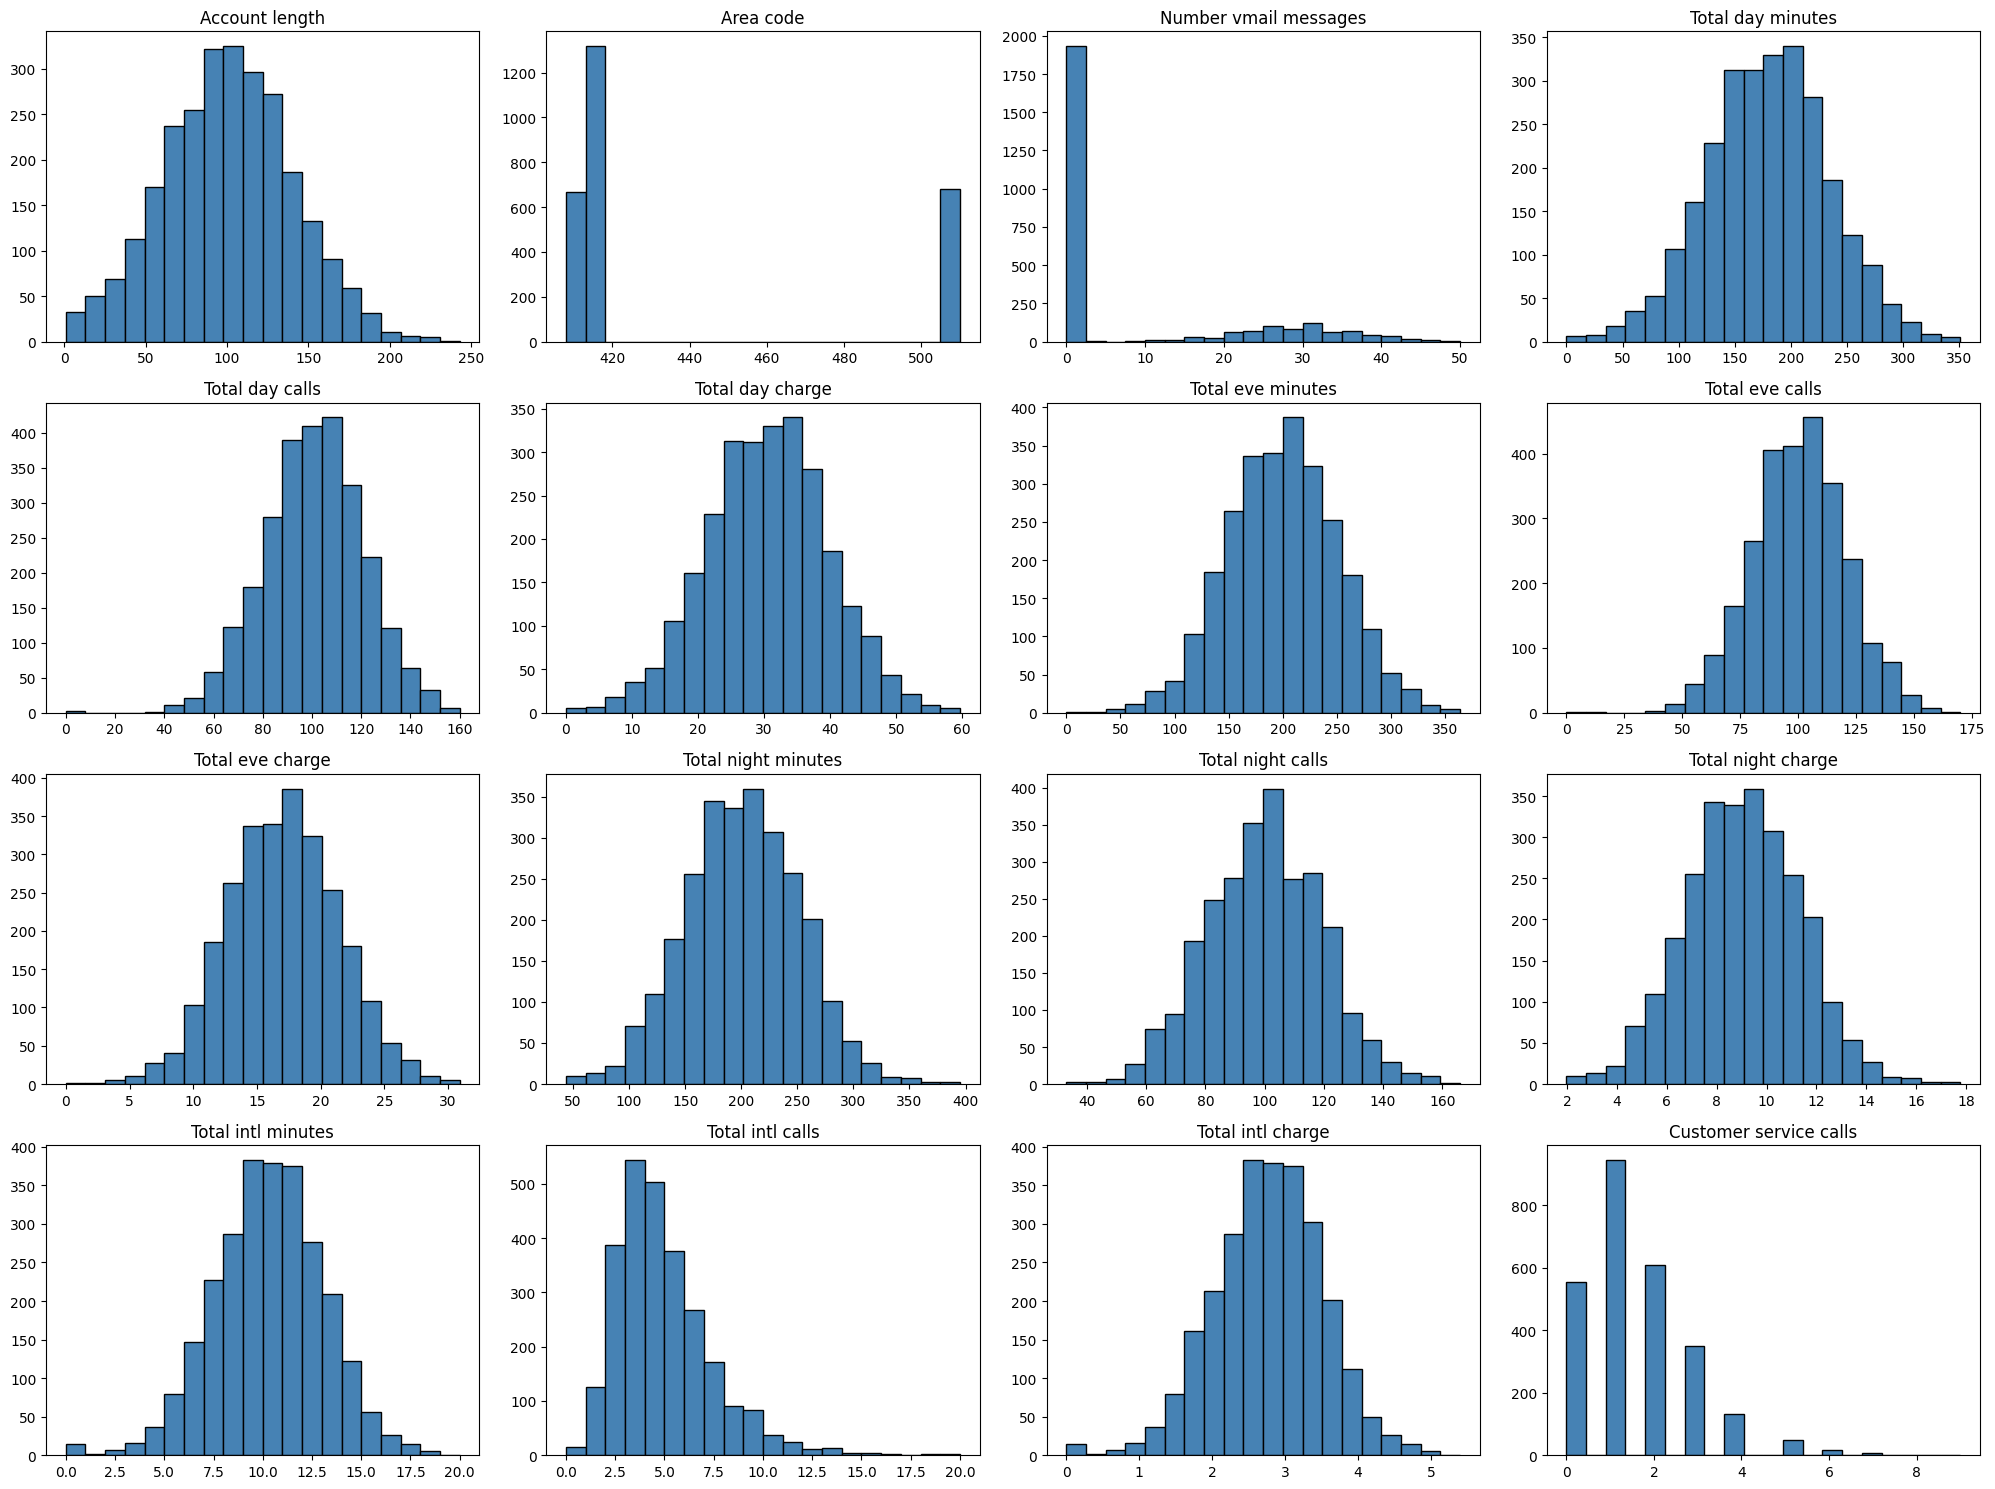

In [16]:
#HISTOGRAM FOR DATA DISTRIBUTION REPRESENTATION OF NUMERICAL FEATURES
data.hist(bins=20, figsize=(20, 15), color='steelblue', edgecolor='black', grid=False)
plt.tight_layout()
plt.show()


In [17]:
#Check the frequency in categories
counts = data['State'].value_counts()
counts

,count
State,
WV,88
MN,70
NY,68
VA,67
WY,66
AL,66
OH,66
OR,62
WI,61


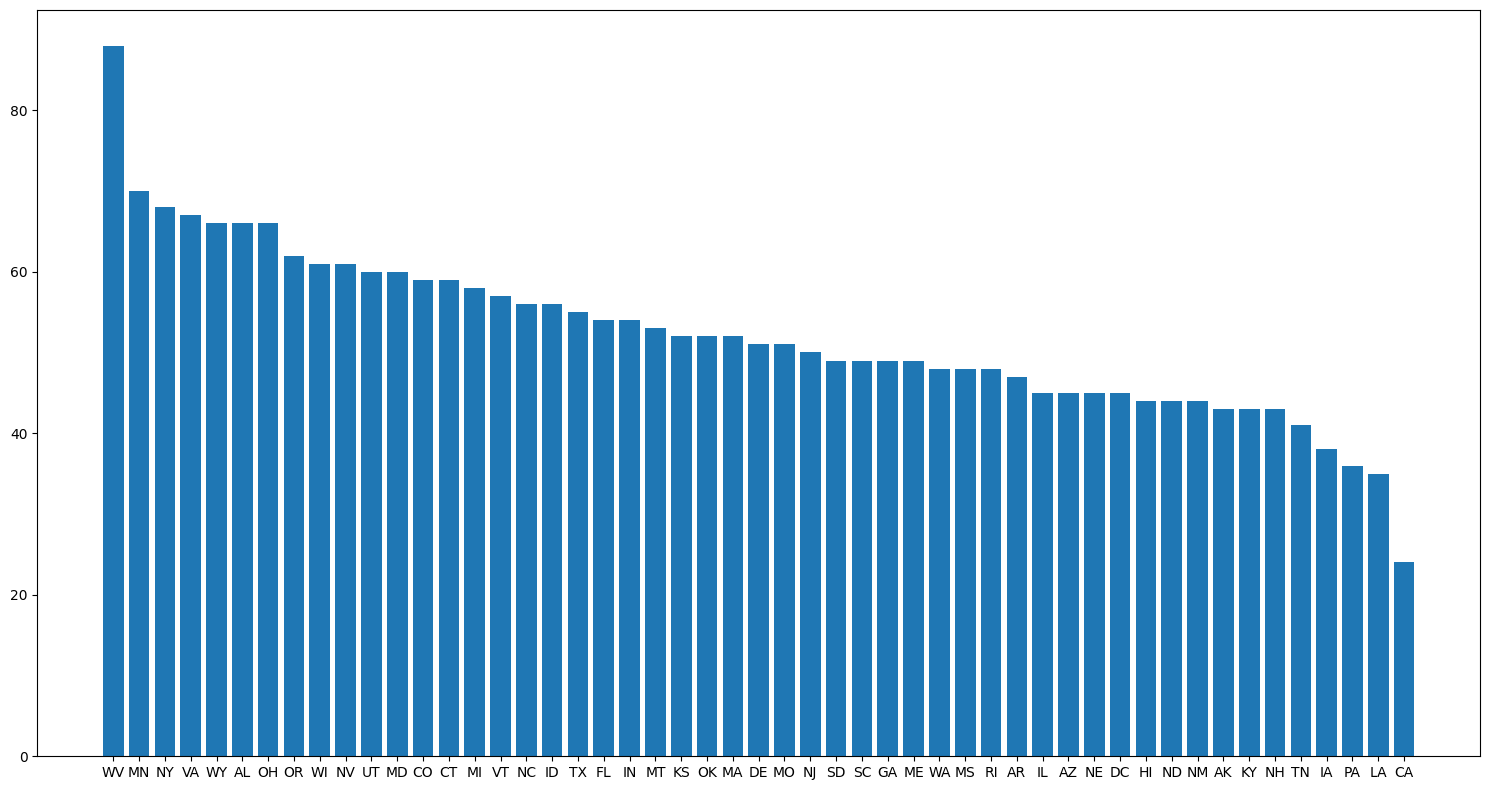

In [18]:
#Visualize Categorical feature 'State'
plt.figure(figsize=(15,8))
plt.bar(counts.index, counts.values)
plt.tight_layout()
plt.show()

In [19]:
#Check frequency in categories
counts = data['International plan'].value_counts()
counts

,count
International plan,
No,2396
Yes,270


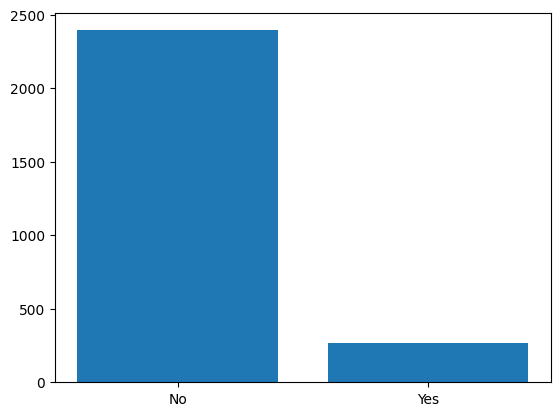

In [20]:
#Visualize Categorical feature 'International plan'
plt.bar(counts.index, counts.values)
plt.show()

In [21]:
#check the frequency in categories
counts = data['Voice mail plan'].value_counts()
counts

,count
Voice mail plan,
No,1933
Yes,733


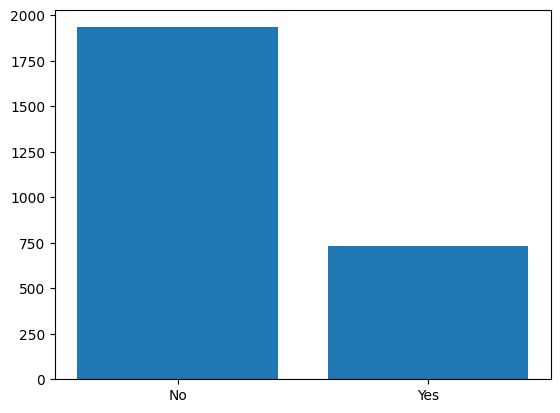

In [22]:
#Visualize Categorical feature 'Voice mail plan'
plt.bar(counts.index, counts.values)
plt.show()

In [23]:
#DROP FEATURES NON-ESSENTIAL FOR PREDICTION AND HIGHLY CORRELATED WITH OTHER FEATURES
ready_data = data.copy()
ready_data.drop(['State','Area code','Total day charge','Total eve charge','Total night charge','Total intl charge'], axis=1, inplace=True)
ready_data.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


BINARY ENCODING OF CATEGORICAL FEATURES FOR TRAINING DATA

In [24]:
ready_data['Churn'] = ready_data['Churn'].map({True:1, False:0})

In [25]:
ready_data['International plan'] = ready_data['International plan'].map({'Yes':1,'No':0})
ready_data['Voice mail plan'] = ready_data['Voice mail plan'].map({'Yes':1,'No':0})

In [26]:
ready_data.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,107,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,137,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,84,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,75,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


In [27]:
#DROP SOME FEATURES IN THE TESTING DATASET
test_data.drop(['State','Area code','Total day charge','Total eve charge','Total night charge','Total intl charge'], axis=1, inplace=True)

In [28]:
#BINARY ENCODING FOR CATEGORICAL FEATURES IN THE TESTING DATASET
test_data['Churn'] = test_data['Churn'].map({True:1, False:0})
test_data['International plan'] = test_data['International plan'].map({'Yes':1,'No':0})
test_data['Voice mail plan'] = test_data['Voice mail plan'].map({'Yes':1,'No':0})
test_data.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,117,0,0,0,184.5,97,351.6,80,215.8,90,8.7,4,1,0
1,65,0,0,0,129.1,137,228.5,83,208.8,111,12.7,6,4,1
2,161,0,0,0,332.9,67,317.8,97,160.6,128,5.4,9,4,1
3,111,0,0,0,110.4,103,137.3,102,189.6,105,7.7,6,2,0
4,49,0,0,0,119.3,117,215.1,109,178.7,90,11.1,1,1,0


SEPARATE THE FEATURES AND TARGETS

In [29]:
x_train = ready_data.drop(['Churn'], axis=1)
y_train = ready_data['Churn']

x_test = test_data.drop(['Churn'], axis=1)
y_test = test_data['Churn']

In [30]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((2666, 13), (2666,), (667, 13), (667,))

FEATURE SCALING

In [31]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

BUILD TRAINING MODEL

In [32]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

LogisticRegression()

PREDICTIONS

In [33]:
y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

EVALUATE THE MODEL

In [34]:
columns = ['Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall',
           'Test_Accuracy', 'Test_Precision', 'Test_Recall']

model_eval_results = pd.DataFrame(columns=columns)

In [35]:
#Evaluate the model on Training data
train_accuracy_score = accuracy_score(y_train,y_train_pred)
train_precision_score = precision_score(y_train,y_train_pred)
train_recall_score = recall_score(y_train,y_train_pred)

#Evaluate the model on Testing data
test_accuracy_score = accuracy_score(y_test,y_test_pred)
test_precision_score = precision_score(y_test,y_test_pred)
test_recall_score = recall_score(y_test,y_test_pred)

model_eval_results.loc[0] = [
    'Logistic Regression',
    train_accuracy_score, train_precision_score, train_recall_score,
    test_accuracy_score, test_precision_score, test_recall_score
]
model_eval_results

,Model,Train_Accuracy,Train_Precision,Train_Recall,Test_Accuracy,Test_Precision,Test_Recall
0,Logistic Regression,0.862716,0.575342,0.216495,0.854573,0.473684,0.189474


In [36]:
#Roc curve evaluation
y_train_probability = model.predict_proba(x_train_scaled)[:,1]
#On train data
train_fpr, train_tpr, train_tresholds = roc_curve(y_train, y_train_probability)
train_auc_score = roc_auc_score(y_train, y_train_probability)

#On test data
y_test_probability = model.predict_proba(x_test_scaled)[:,1]
test_fpr, test_tpr, test_tresholds = roc_curve(y_test, y_test_probability)
test_auc_score = roc_auc_score(y_test, y_test_probability)

In [37]:
test_auc_score

np.float64(0.8261501656238498)

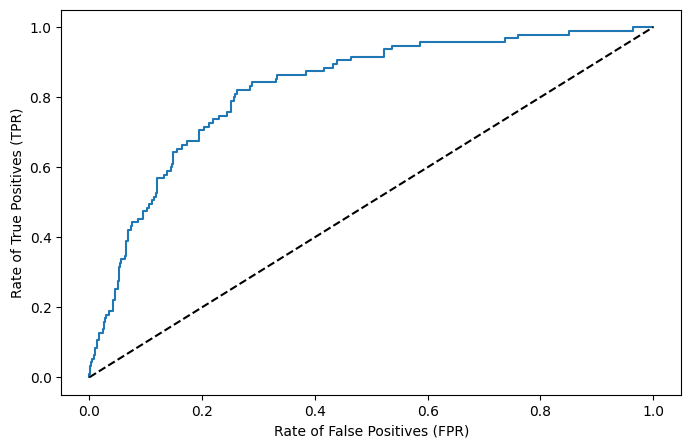

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(test_fpr, test_tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Rate of False Positives (FPR)')
plt.ylabel('Rate of True Positives (TPR)')
plt.grid(False)
plt.show()


In [39]:
#Interpret model coefficients and the odds ratio.
coefficients = model.coef_
odds_ratios = np.exp(coefficients)
odds_ratios_df = pd.DataFrame(odds_ratios[0], x_train.columns)
odds_ratios_df

,0
Account length,1.035409
International plan,1.876546
Voice mail plan,0.445775
Number vmail messages,1.515005
Total day minutes,1.973418
Total day calls,1.058853
Total eve minutes,1.331330
Total eve calls,0.984420
Total night minutes,1.152870
Total night calls,1.038622
